## UNEMPLOYMENT ANALYSIS WITH PYTHON

### STEP 1 : IMPORT REQUIRED LIBRARIES

#### Pandas is used for data manipulation and analysis.

In [1]:
import pandas as pd

#### Matplotlib is used to create graphs and visualizations.

In [2]:
import matplotlib.pyplot as plt

#### Seaborn is an advanced visualization library built on matplotlib.

In [3]:
import seaborn as sns

### STEP 2 : LOAD THE DATASET

#### Read the CSV file and store it inside a DataFrame

In [4]:
df = pd.read_csv("Unemployment_in_India.csv")

### STEP 3 : DATA EXPLORATION

#### Display the first 5 rows of the dataset

In [5]:
print("First 5 Rows:")
print(df.head())

First 5 Rows:
           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  


#### Display dataset information

In [6]:
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
None


#### Display missing values

In [7]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


#### Display statistical summary

In [8]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       Estimated Unemployment Rate (%)  Estimated Employed  \
count                       740.000000        7.400000e+02   
mean                         11.787946        7.204460e+06   
std                          10.721298        8.087988e+06   
min                           0.000000        4.942000e+04   
25%                           4.657500        1.190404e+06   
50%                           8.350000        4.744178e+06   
75%                          15.887500        1.127549e+07   
max                          76.740000        4.577751e+07   

       Estimated Labour Participation Rate (%)  
count                               740.000000  
mean                                 42.630122  
std                                   8.111094  
min                                  13.330000  
25%                                  38.062500  
50%                                  41.160000  
75%                                  45.505000  
max                        

### STEP 4 : DATA CLEANING

#### Remove unnecessary spaces from column names

In [9]:
df.columns = df.columns.str.strip()

#### Convert Date column from string format into datetime format

In [10]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

### STEP 5 : SET GRAPH STYLE

#### Apply a white background with grid lines

In [11]:
sns.set_style("whitegrid")

### VISUALIZATION 1 : DISTRIBUTION OF UNEMPLOYMENT RATE

#### Create histogram

<Axes: title={'center': 'Distribution of Unemployment Rate'}, xlabel='Unemployment Rate (%)', ylabel='Count'>

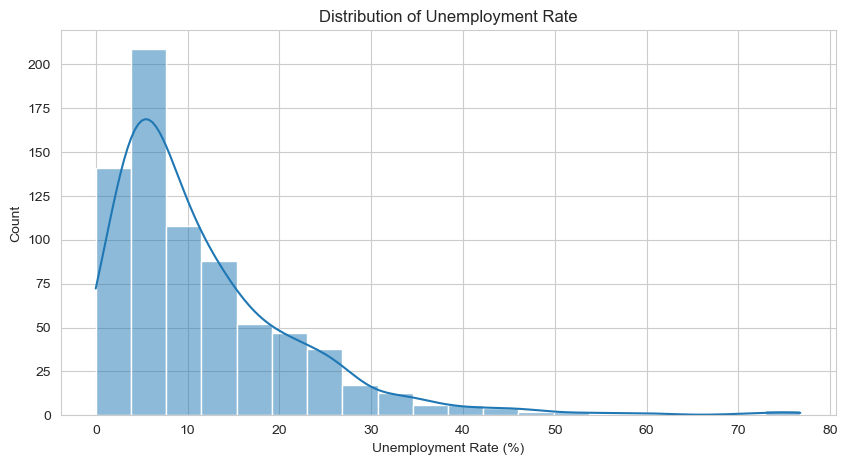

In [12]:
# Create a figure with width=10 and height=5
plt.figure(figsize=(10,5))

# Set graph title
plt.title("Distribution of Unemployment Rate")

# Label X-axis
plt.xlabel("Unemployment Rate (%)")

# Label Y-axis
plt.ylabel("Count")

# Histogram shows frequency distribution.
sns.histplot(df['Estimated Unemployment Rate (%)'], bins=20, kde=True)

### VISUALIZATION 2 : STATE-WISE AVERAGE UNEMPLOYMENT RATE

#### Group records according to state name

In [13]:
state_unemployment = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

#### Create bar chart

Text(0, 0.5, 'Average Unemployment Rate (%)')

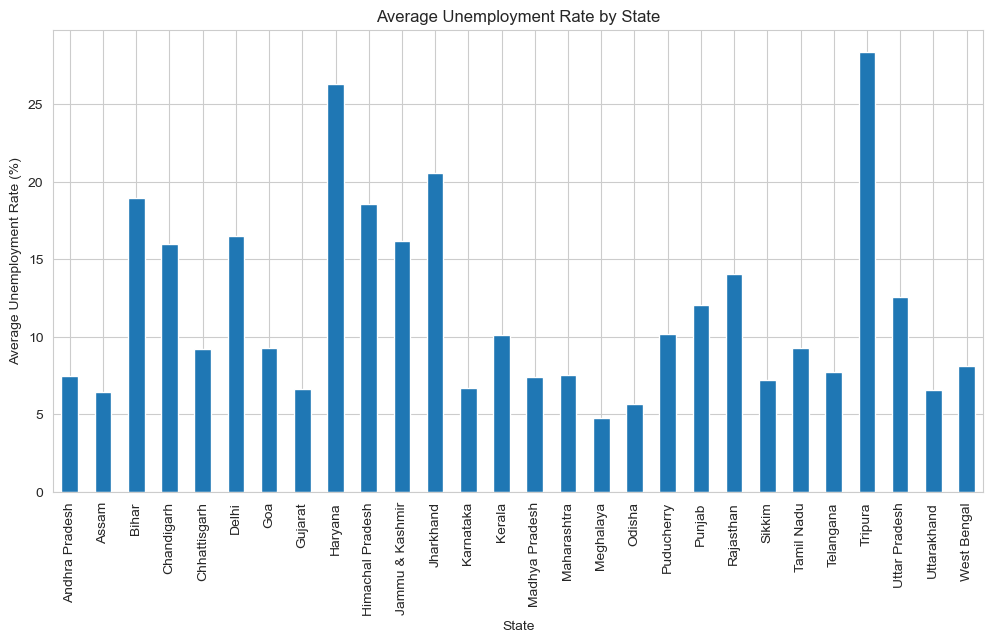

In [14]:
# Sort values in ascending order and 
state_unemployment.sort_values()

# Create graph canvas
plt.figure(figsize=(12,6))

# Graph title
plt.title("Average Unemployment Rate by State")

# Rotate state names by 90 degrees
plt.xticks(rotation=90)

# Plot graph 
state_unemployment.plot(kind = 'bar')

# X-axis label
plt.xlabel("State")

# Y-axis label
plt.ylabel("Average Unemployment Rate (%)")

### VISUALIZATION 3  : URBAN VS RURAL UNEMPLOYMENT

#### Create Boxplot

<Axes: title={'center': 'Urban vs Rural Unemployment'}, xlabel='Area', ylabel='Estimated Unemployment Rate (%)'>

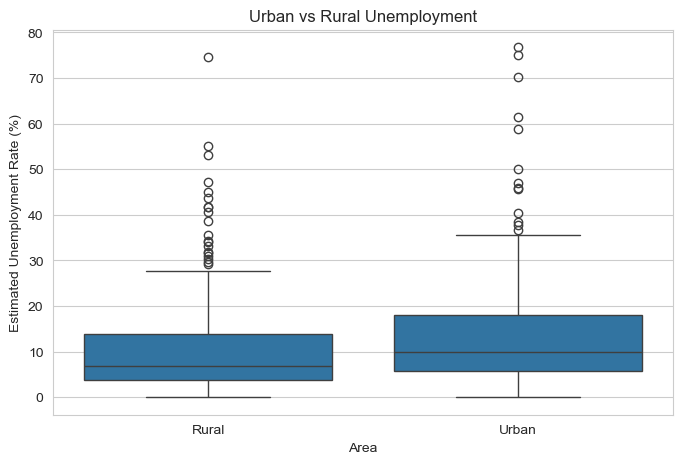

In [15]:
# Create graph canvas
plt.figure(figsize=(8,5))

# Graph title
plt.title("Urban vs Rural Unemployment")

# Boxplot compares unemployment rates between Urban and Rural areas.
sns.boxplot(x='Area', y='Estimated Unemployment Rate (%)', data=df)

### VISUALIZATION 4 : MONTHLY UNEMPLOYMENT TREND

#### Extract month from Date column

In [16]:
monthly_data = df.groupby(df['Date'].dt.month)['Estimated Unemployment Rate (%)'].mean()

#### Create line graph

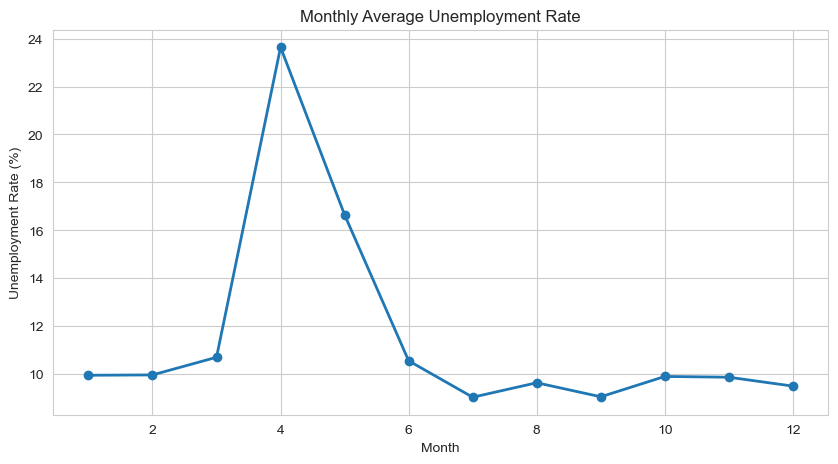

In [17]:
# Create graph canvas
plt.figure(figsize=(10,5))

# Title
plt.title("Monthly Average Unemployment Rate")

# Plot graph
monthly_data.plot(marker = 'o', linewidth = 2)

# X-axis label
plt.xlabel("Month")

# Y-axis label
plt.ylabel("Unemployment Rate (%)")

# Display grid
plt.grid(True)

### VISUALIZATION 5 : TOP 10 STATES WITH HIGHEST UNEMPLOYMENT

#### Sort unemployment rates in descending order

In [18]:
top10 = state_unemployment.sort_values(ascending=False).head(10)

#### Create horizontal bar chart

<Axes: title={'center': 'Top 10 States with Highest Unemployment'}, xlabel='Unemployment Rate (%)', ylabel='State'>

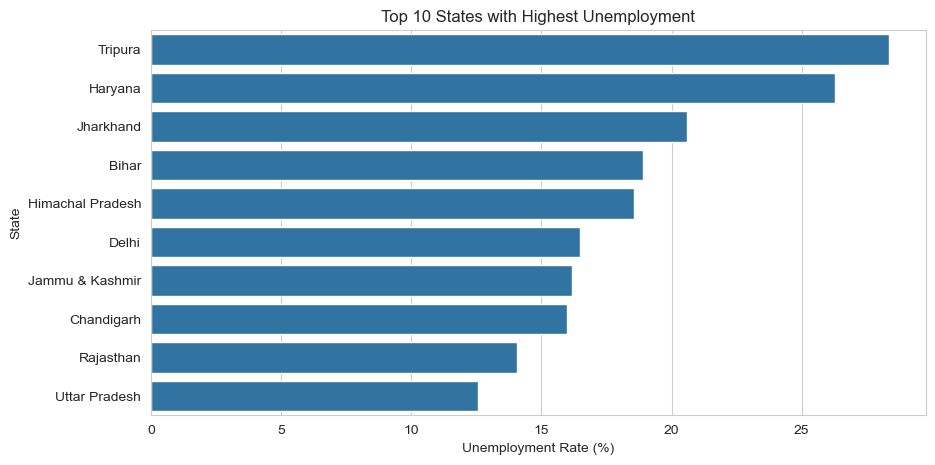

In [19]:
# Create graph canvas
plt.figure(figsize=(10,5))

# Graph title
plt.title("Top 10 States with Highest Unemployment")

# X-axis label
plt.xlabel("Unemployment Rate (%)")

# Y-axis label
plt.ylabel("State")

# Plot graph
sns.barplot(x = top10.values, y = top10.index)

### VISUALIZATION 6 : CORRELATION HEATMAP

#### Select only numerical columns

In [20]:
numeric_df = df.select_dtypes(include='number')

#### Create Heatmap

Text(0.5, 1.0, 'Correlation Heatmap')

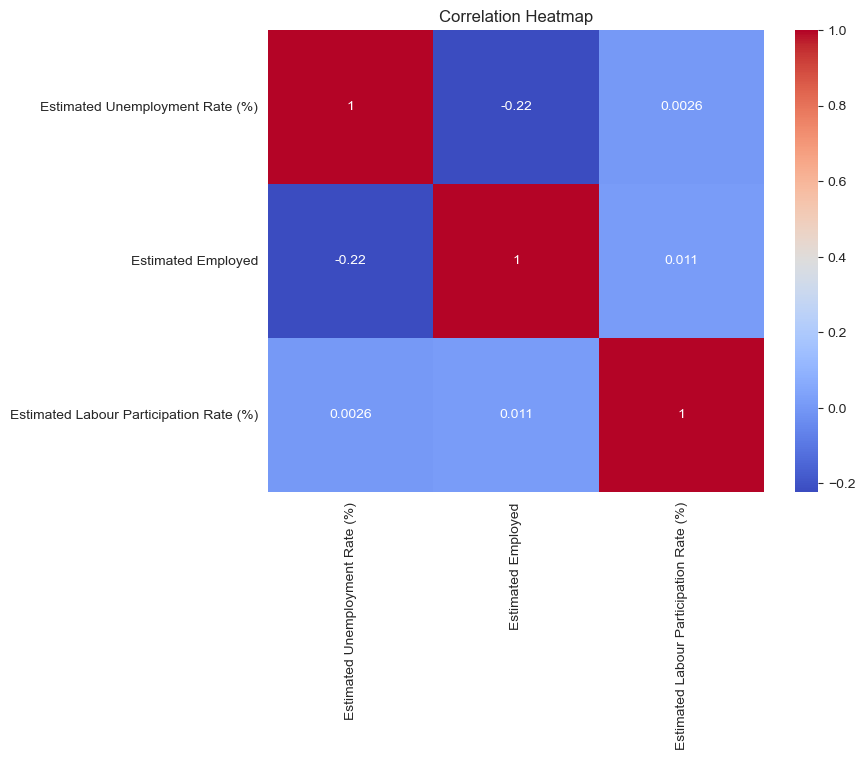

In [21]:
# Create graph canvas
plt.figure(figsize=(8,6))

# Calculate correlation matrix.
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

# Graph title
plt.title("Correlation Heatmap")

### STEP 6 : INSIGHTS

In [22]:
print("\n=========== INSIGHTS ===========")

# Calculate average unemployment rate
print("\nAverage Unemployment Rate:")
print(round(df['Estimated Unemployment Rate (%)'].mean(), 2), "%")

# State with highest unemployment
print("\nState with Highest Unemployment:")
print(state_unemployment.idxmax())

# Highest unemployment percentage
print("\nHighest Unemployment Rate:")
print(round(state_unemployment.max(), 2), "%")

# State with lowest unemployment
print("\nState with Lowest Unemployment:")
print(state_unemployment.idxmin())

# Lowest unemployment percentage
print(round(state_unemployment.min(), 2), "%")


=========== INSIGHTS ===========

Average Unemployment Rate:
11.79 %

State with Highest Unemployment:
Tripura

Highest Unemployment Rate:
28.35 %

State with Lowest Unemployment:
Meghalaya
4.8 %
